In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12,6)

In [3]:
df = pd.read_csv('../data/Superstore.csv', encoding="latin1")


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [5]:
df.shape

(9994, 21)

# Business Overview

The objective of this analysis is to understand:

- Sales Performance
- Profitability
- Customer Behaviour
- Product Performance
- Regional Performance
- Shipping Analysis

In [19]:
def display_kpi(title, value):

    print(f"{title:.<30} {value}")

print("="*55)
print("📊 RETAIL SALES DASHBOARD")
print("="*55)

display_kpi("💰 Total Sales",
            f"${df['Sales'].sum():,.2f}")

display_kpi("📈 Total Profit",
            f"${df['Profit'].sum():,.2f}")

display_kpi("🛒 Total Orders",
            f"{df['Order ID'].nunique():,}")

display_kpi("👥 Customers",
            f"{df['Customer ID'].nunique():,}")

display_kpi("📦 Products",
            f"{df['Product ID'].nunique():,}")

display_kpi("💵 Avg Order Value",
            f"${df['Sales'].mean():,.2f}")

print("="*55)

📊 RETAIL SALES DASHBOARD
💰 Total Sales................. $2,297,200.86
📈 Total Profit................ $286,397.02
🛒 Total Orders................ 5,009
👥 Customers................... 793
📦 Products.................... 1,862
💵 Avg Order Value............. $229.86


In [20]:
kpi = pd.DataFrame({

    "KPI":[
        "💰 Total Sales",
        "📈 Total Profit",
        "🛒 Orders",
        "👥 Customers",
        "📦 Products",
        "💵 Avg Order Value"
    ],

    "Value":[
        f"${df['Sales'].sum():,.2f}",
        f"${df['Profit'].sum():,.2f}",
        f"{df['Order ID'].nunique():,}",
        f"{df['Customer ID'].nunique():,}",
        f"{df['Product ID'].nunique():,}",
        f"${df['Sales'].mean():,.2f}"
    ]

})

kpi

,KPI,Value
0,💰 Total Sales,"$2,297,200.86"
1,📈 Total Profit,"$286,397.02"
2,🛒 Orders,"5,009"
3,👥 Customers,793
4,📦 Products,"1,862"
5,💵 Avg Order Value,$229.86


## Business Observation

The retail business generated **$2,297,200.86** in revenue with a total profit of **$286,397.02**.

The dataset contains **5,009 orders**, served by **793 unique customers**, covering **1862 products**.

These KPIs provide an overall snapshot of the business before drilling down into detailed analysis.

# 🛒 Retail Sales Analysis

## Project Objective

The objective of this project is to analyze retail sales data and uncover meaningful business insights using Python, PostgreSQL, SQL, and Power BI.

The analysis focuses on:

- Sales Performance
- Profitability
- Customer Behaviour
- Product Performance
- Regional Analysis
- Shipping Performance

---

# 📂 Category Analysis

In this section, we analyze the performance of each product category.

We aim to answer:

- Which category generates the highest revenue?
- Which category is the most profitable?
- Which category sells the most products?
- Which category receives the highest discount?

In [22]:
category_summary = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Average_Discount=("Discount", "mean"),
          Total_Orders=("Order ID", "nunique")
      )
      .sort_values(by="Total_Sales", ascending=False)
)

category_summary

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Total_Orders
Category,,,,,
Technology,836154.0330,145454.9481,6939,0.132323,1544
Furniture,741999.7953,18451.2728,8028,0.173923,1764
Office Supplies,719047.0320,122490.8008,22906,0.157285,3742


In [23]:
category_summary.style.format({

    "Total_Sales":"${:,.2f}",
    "Total_Profit":"${:,.2f}",
    "Average_Discount":"{:.2%}"

}).background_gradient(cmap="Blues")

,Total_Sales,Total_Profit,Total_Quantity,Average_Discount,Total_Orders
Category,,,,,
Technology,"$836,154.03","$145,454.95",6939,13.23%,1544
Furniture,"$741,999.80","$18,451.27",8028,17.39%,1764
Office Supplies,"$719,047.03","$122,490.80",22906,15.73%,3742


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


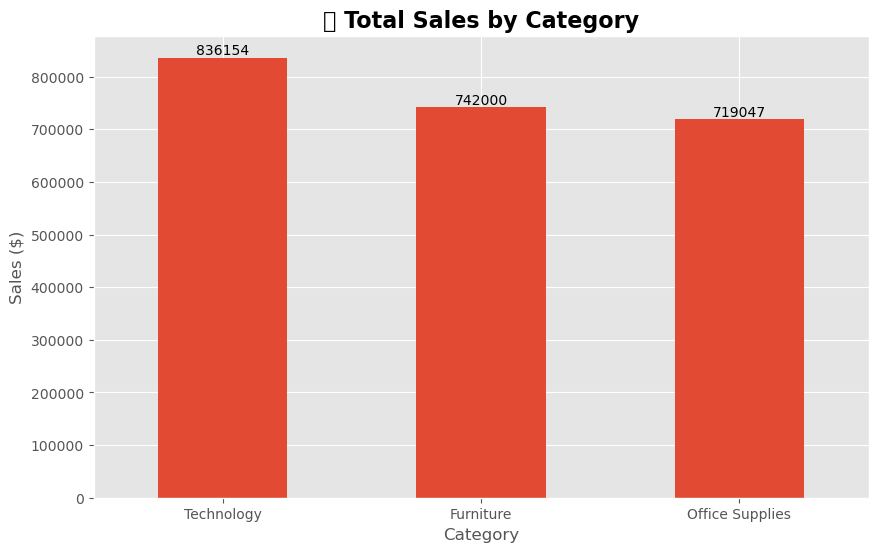

In [24]:
ax = category_summary["Total_Sales"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("💰 Total Sales by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

## 📌 Observation

Technology generated the highest total revenue among all product categories, making it the primary revenue driver for the business.

Furniture also contributed significantly to sales but should be compared against profitability to evaluate whether high sales translate into strong financial performance.

Office Supplies maintained consistent sales and may represent a stable revenue source.

C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


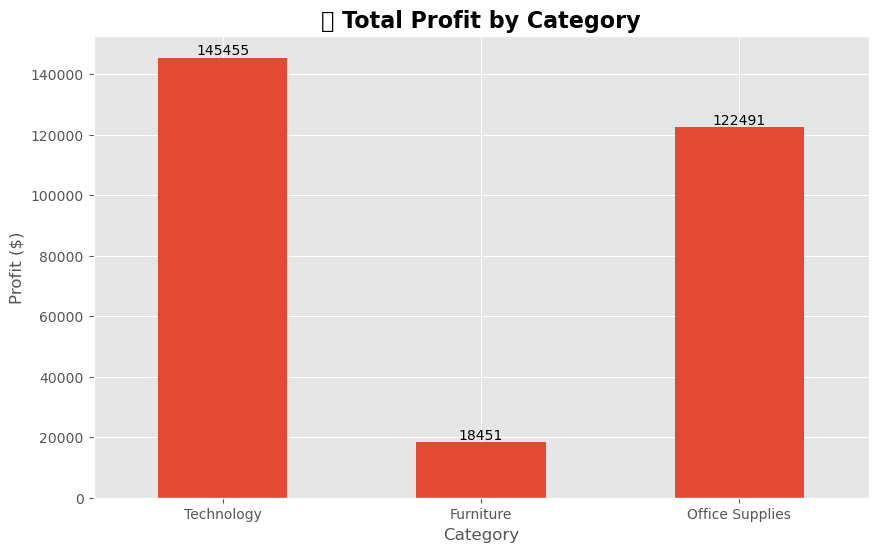

In [25]:
ax = category_summary["Total_Profit"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("📈 Total Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

## 📌 Observation

Although Furniture contributes a large portion of revenue, its profit should be compared with Technology to determine whether lower margins or higher discounts are affecting profitability.

Technology appears to generate strong revenue while maintaining healthy profits, making it an important business category.

C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


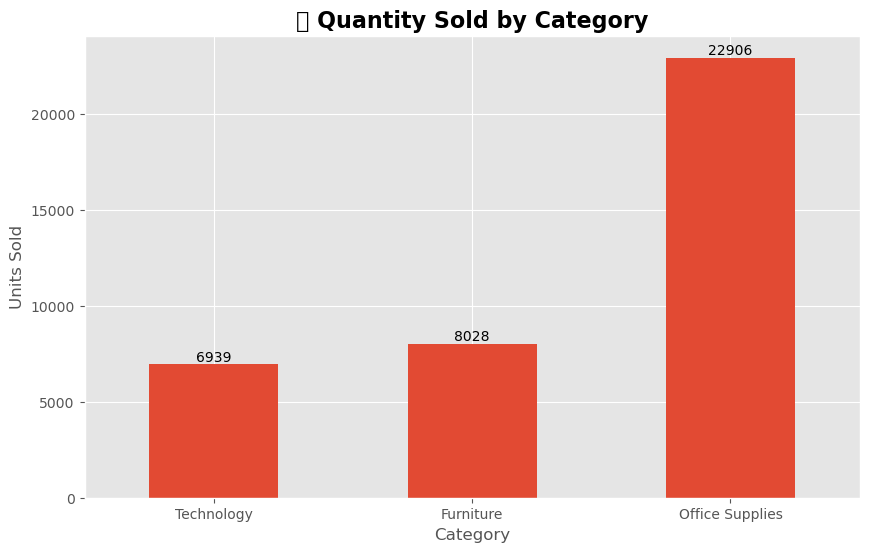

In [26]:
ax = category_summary["Total_Quantity"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("📦 Quantity Sold by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


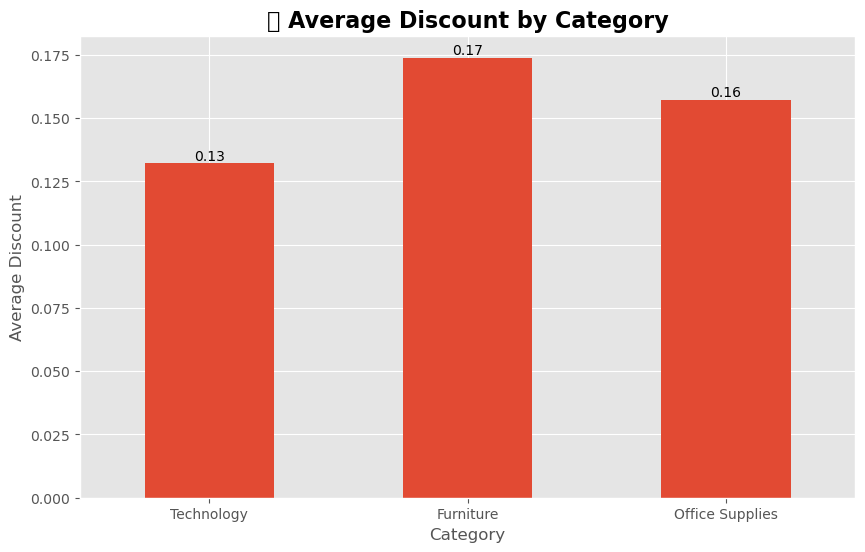

In [27]:
ax = category_summary["Average_Discount"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("🏷️ Average Discount by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Average Discount")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

# ✅ Category Analysis Conclusion

Technology is the strongest-performing category in terms of revenue and profitability.

Furniture contributes substantial revenue but should be monitored for profit margins and discount strategy.

Office Supplies provides steady sales volume and represents a consistent contributor to overall business performance.

These findings suggest that future marketing and inventory strategies should prioritize high-performing categories while optimizing margins for lower-performing ones.

# 👥 Customer Analysis

Customers are the backbone of every retail business.

In this section, we will identify:

- Top Revenue Generating Customers
- Most Profitable Customers
- Loss Making Customers
- Customer Segments
- Average Spending per Customer
- Business Recommendations

In [28]:
customer_summary = (

    df.groupby(["Customer ID","Customer Name"])

    .agg(

        Total_Sales=("Sales","sum"),
        Total_Profit=("Profit","sum"),
        Orders=("Order ID","nunique"),
        Total_Quantity=("Quantity","sum"),
        Avg_Discount=("Discount","mean")

    )

    .sort_values(
        by="Total_Sales",
        ascending=False
    )

)

customer_summary.head(10)

,,Total_Sales,Total_Profit,Orders,Total_Quantity,Avg_Discount
Customer ID,Customer Name,,,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5,50,0.246667
TC-20980,Tamara Chand,19052.218,8981.3239,5,42,0.116667
RB-19360,Raymond Buch,15117.339,6976.0959,6,71,0.094444
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,0.080000
AB-10105,Adrian Barton,14473.571,5444.8055,10,73,0.240000
KL-16645,Ken Lonsdale,14175.229,806.8550,12,113,0.200000
SC-20095,Sanjit Chand,14142.334,5757.4119,9,87,0.063636
HL-15040,Hunter Lopez,12873.298,5622.4292,6,50,0.018182
SE-20110,Sanjit Engle,12209.438,2650.6769,11,78,0.110526


In [29]:
customer_summary.style.format({

    "Total_Sales":"${:,.2f}",
    "Total_Profit":"${:,.2f}",
    "Avg_Discount":"{:.2%}"

}).background_gradient(cmap="Greens")

,,Total_Sales,Total_Profit,Orders,Total_Quantity,Avg_Discount
Customer ID,Customer Name,,,,,
SM-20320,Sean Miller,"$25,043.05","$-1,980.74",5,50,24.67%
TC-20980,Tamara Chand,"$19,052.22","$8,981.32",5,42,11.67%
RB-19360,Raymond Buch,"$15,117.34","$6,976.10",6,71,9.44%
TA-21385,Tom Ashbrook,"$14,595.62","$4,703.79",4,36,8.00%
AB-10105,Adrian Barton,"$14,473.57","$5,444.81",10,73,24.00%
KL-16645,Ken Lonsdale,"$14,175.23",$806.86,12,113,20.00%
SC-20095,Sanjit Chand,"$14,142.33","$5,757.41",9,87,6.36%
HL-15040,Hunter Lopez,"$12,873.30","$5,622.43",6,50,1.82%
SE-20110,Sanjit Engle,"$12,209.44","$2,650.68",11,78,11.05%


In [30]:
top10 = customer_summary.head(10)

top10

,,Total_Sales,Total_Profit,Orders,Total_Quantity,Avg_Discount
Customer ID,Customer Name,,,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5,50,0.246667
TC-20980,Tamara Chand,19052.218,8981.3239,5,42,0.116667
RB-19360,Raymond Buch,15117.339,6976.0959,6,71,0.094444
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,0.080000
AB-10105,Adrian Barton,14473.571,5444.8055,10,73,0.240000
KL-16645,Ken Lonsdale,14175.229,806.8550,12,113,0.200000
SC-20095,Sanjit Chand,14142.334,5757.4119,9,87,0.063636
HL-15040,Hunter Lopez,12873.298,5622.4292,6,50,0.018182
SE-20110,Sanjit Engle,12209.438,2650.6769,11,78,0.110526


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


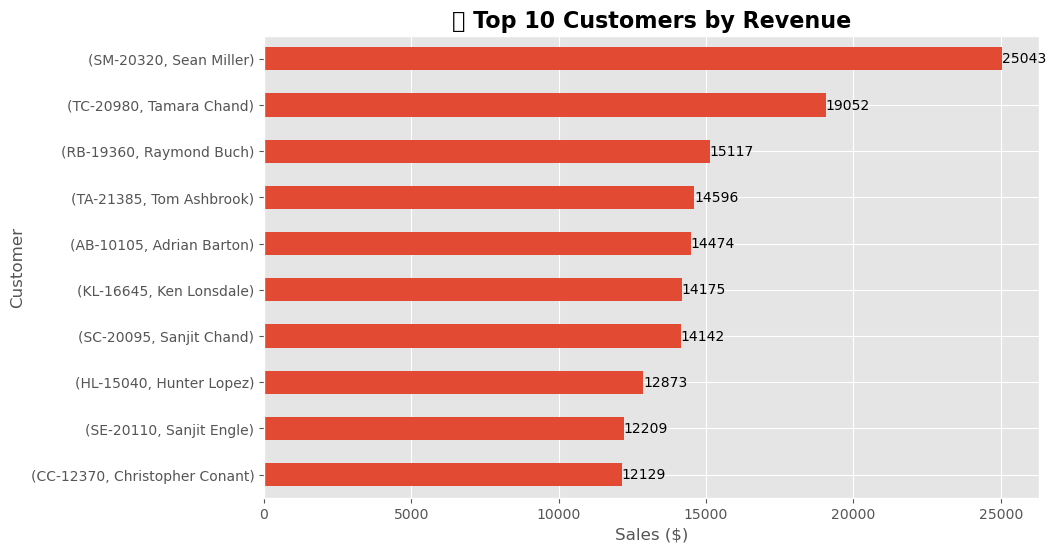

In [31]:
ax = top10["Total_Sales"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title(
    "🏆 Top 10 Customers by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales ($)")
plt.ylabel("Customer")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

## 📌 Observation

A small group of customers contributes a significant portion of total revenue.

These customers represent high-value business relationships and should be prioritized through loyalty programs and personalized marketing initiatives.

Losing even a few of these customers could significantly impact overall revenue.

In [32]:
top_profit = (

customer_summary

.sort_values(

by="Total_Profit",

ascending=False

)

.head(10)

)

top_profit

,,Total_Sales,Total_Profit,Orders,Total_Quantity,Avg_Discount
Customer ID,Customer Name,,,,,
TC-20980,Tamara Chand,19052.218,8981.3239,5,42,0.116667
RB-19360,Raymond Buch,15117.339,6976.0959,6,71,0.094444
SC-20095,Sanjit Chand,14142.334,5757.4119,9,87,0.063636
HL-15040,Hunter Lopez,12873.298,5622.4292,6,50,0.018182
AB-10105,Adrian Barton,14473.571,5444.8055,10,73,0.240000
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,0.080000
CM-12385,Christopher Martinez,8954.020,3899.8904,4,34,0.120000
KD-16495,Keith Dawkins,8181.256,3038.6254,12,84,0.087500
AR-10540,Andy Reiter,6608.448,2884.6208,6,33,0.066667


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


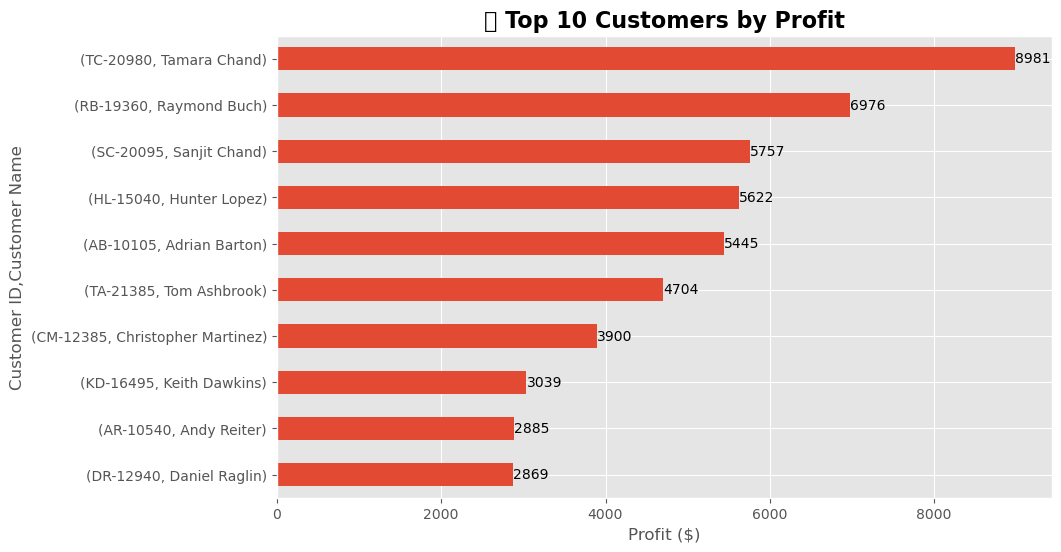

In [33]:
ax = top_profit["Total_Profit"].sort_values().plot(

kind="barh",

figsize=(10,6)

)

plt.title(

"💰 Top 10 Customers by Profit",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Profit ($)")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 📌 Business Insight

The customers generating the highest revenue are not always the most profitable.

A detailed profitability analysis helps identify customers that contribute positively to the business instead of focusing solely on sales volume.

In [34]:
loss_customers = (

customer_summary

.sort_values(

by="Total_Profit"

)

.head(10)

)

loss_customers

,,Total_Sales,Total_Profit,Orders,Total_Quantity,Avg_Discount
Customer ID,Customer Name,,,,,
CS-12505,Cindy Stewart,5690.055,-6626.3895,6,40,0.200000
GT-14635,Grant Thornton,9351.212,-4108.6589,3,26,0.250000
LF-17185,Luke Foster,3930.509,-3583.9770,7,69,0.318750
SR-20425,Sharelle Roach,3233.481,-3333.9144,5,34,0.366667
HG-14965,Henry Goldwyn,3247.642,-2797.9635,12,68,0.170588
NC-18415,Nathan Cano,2218.990,-2204.8072,6,38,0.264286
SB-20290,Sean Braxton,8057.891,-2082.7451,7,84,0.241176
SM-20320,Sean Miller,25043.050,-1980.7393,5,50,0.246667
CP-12340,Christine Phan,5888.275,-1850.3029,8,59,0.213333


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


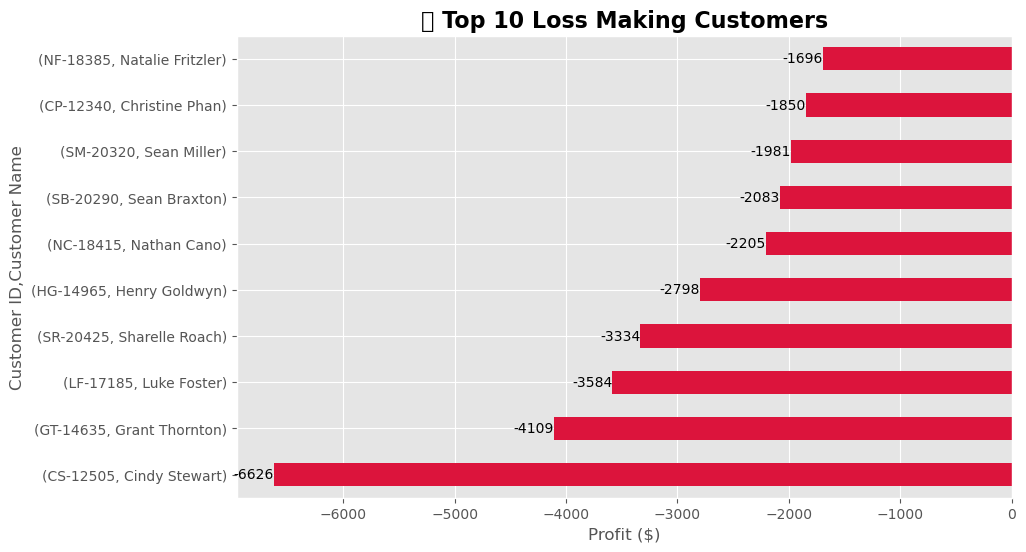

In [35]:
ax = loss_customers["Total_Profit"].plot(

kind="barh",

figsize=(10,6),

color="crimson"

)

plt.title(

"📉 Top 10 Loss Making Customers",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Profit ($)")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 📌 Observation

Some customers consistently generate negative profits despite contributing to revenue.

Possible reasons include:

- High discounts
- Expensive shipping
- Low-margin products
- High return rates (not available in this dataset)

These customers should be investigated before implementing pricing or discount strategies.

In [36]:
customer_summary["Average_Order_Value"] = (

customer_summary["Total_Sales"]

/

customer_summary["Orders"]

)

customer_summary.head()

,,Total_Sales,Total_Profit,Orders,Total_Quantity,Avg_Discount,Average_Order_Value
Customer ID,Customer Name,,,,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5,50,0.246667,5008.6100
TC-20980,Tamara Chand,19052.218,8981.3239,5,42,0.116667,3810.4436
RB-19360,Raymond Buch,15117.339,6976.0959,6,71,0.094444,2519.5565
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,0.080000,3648.9050
AB-10105,Adrian Barton,14473.571,5444.8055,10,73,0.240000,1447.3571


In [38]:
customer_summary.sort_values(

by="Average_Order_Value",

ascending=False

).head(10)

,,Total_Sales,Total_Profit,Orders,Total_Quantity,Avg_Discount,Average_Order_Value
Customer ID,Customer Name,,,,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5,50,0.246667,5008.610000
TC-20980,Tamara Chand,19052.218,8981.3239,5,42,0.116667,3810.443600
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,0.080000,3648.905000
GT-14635,Grant Thornton,9351.212,-4108.6589,3,26,0.250000,3117.070667
BM-11140,Becky Martin,11789.630,-1659.9581,4,64,0.168750,2947.407500
MW-18235,Mitch Willingham,5253.876,1665.5160,2,13,0.066667,2626.938000
RB-19360,Raymond Buch,15117.339,6976.0959,6,71,0.094444,2519.556500
CC-12370,Christopher Conant,12129.072,2177.0493,5,34,0.281818,2425.814400
PF-19120,Peter Fuller,9062.864,-614.2943,4,75,0.121053,2265.716000


# ✅ Customer Analysis Conclusion

Key Findings:

- A small percentage of customers contribute disproportionately to total revenue.
- High revenue customers are not always the most profitable.
- Several customers generate negative profit, indicating potential pricing or discount issues.
- Customer retention strategies should prioritize high-profit customers instead of focusing only on revenue.

Business Recommendation:

Implement a customer segmentation strategy that rewards profitable customers while reviewing pricing and discount policies for loss-making customers.